# Bank Customer Churn — Multi-Algorithm Builder Project
### Same dataset, builder's hat: train many algorithms and pick the best

**Goal:** predict whether a bank customer will **churn** (`Exited = 1`) or **stay** (`0`). This is a **binary classification** problem on 10,000 customers.

Unlike the validation version, here we act as a **model builder**: we prepare the data once, then train a whole lineup of classification algorithms on it, compare them on the same footing, and choose the strongest one — then squeeze a bit more out of it.

**Algorithms we'll train:**
1. Logistic Regression  2. K-Nearest Neighbours  3. Gaussian Naive Bayes  4. Decision Tree  5. Random Forest  6. Extra Trees  7. AdaBoost  8. Gradient Boosting  9. XGBoost  10. Support Vector Machine  11. Neural Network (MLP)

## 1. Setup

In [1]:
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, roc_curve, confusion_matrix,
                             classification_report)

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, GradientBoostingClassifier)
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier

import warnings; warnings.filterwarnings('ignore')
SEED = 42
np.random.seed(SEED)

## 2. Load and explore

In [2]:
df = pd.read_csv('Churn_Modelling.csv')
print('Shape:', df.shape)
df.head()

Shape: (10000, 14)


,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Exited
0    7963
1    2037
Name: count, dtype: int64
Exited
0    79.6%
1    20.4%
Name: proportion, dtype: str


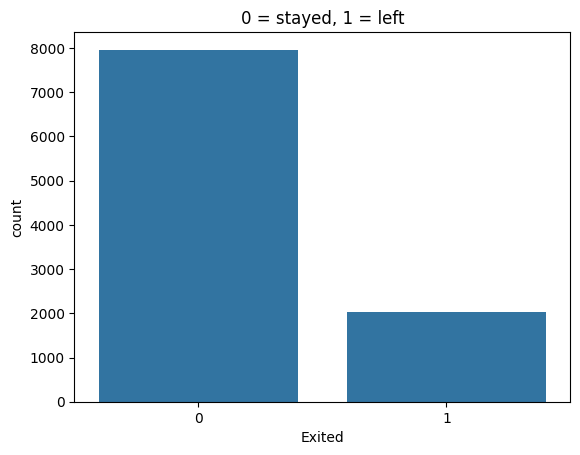

In [3]:
# Target balance: how many left vs stayed
print(df['Exited'].value_counts())
print((df['Exited'].value_counts(normalize=True)*100).round(1).astype(str) + '%')
sns.countplot(x='Exited', data=df); plt.title('0 = stayed, 1 = left'); plt.show()

About **80% stay, 20% leave** — imbalanced. We'll watch **recall** (how many real leavers we catch), not just accuracy.

## 3. Prepare the data (once, for every model)
Drop the ID columns, one-hot encode the two text columns, split 80/20 (stratified), and scale.

In [4]:
data = df.drop(['RowNumber','CustomerId','Surname'], axis=1)
X = data.drop('Exited', axis=1)
y = data['Exited']
X = pd.get_dummies(X, columns=['Geography','Gender'])   # words -> 0/1 columns
print('Features:', X.shape[1])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)   # fit on train only
X_test_s  = scaler.transform(X_test)        # apply same scaling to test
print('Train:', X_train_s.shape, ' Test:', X_test_s.shape)

Features: 13
Train: (8000, 13)  Test: (2000, 13)


## 4. Train every algorithm and score it
We put all models in one dictionary, then loop: fit on the training data, predict on the test set, and record five metrics for each. Using the same data and the same loop keeps the comparison fair.

In [5]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=SEED),
    'K-Nearest Neighbours': KNeighborsClassifier(n_neighbors=11),
    'Gaussian Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(max_depth=6, random_state=SEED),
    'Random Forest': RandomForestClassifier(n_estimators=300, random_state=SEED),
    'Extra Trees': ExtraTreesClassifier(n_estimators=300, random_state=SEED),
    'AdaBoost': AdaBoostClassifier(random_state=SEED),
    'Gradient Boosting': GradientBoostingClassifier(random_state=SEED),
    'XGBoost': XGBClassifier(eval_metric='logloss', random_state=SEED),
    'SVM (RBF)': SVC(probability=True, random_state=SEED),
    'Neural Net (MLP)': MLPClassifier(hidden_layer_sizes=(16,8), max_iter=500, random_state=SEED),
}

rows = []
roc_data = {}
for name, model in models.items():
    model.fit(X_train_s, y_train)
    pred = model.predict(X_test_s)
    proba = model.predict_proba(X_test_s)[:, 1]
    rows.append({
        'Model': name,
        'Accuracy':  accuracy_score(y_test, pred),
        'Precision': precision_score(y_test, pred),
        'Recall':    recall_score(y_test, pred),
        'F1':        f1_score(y_test, pred),
        'ROC_AUC':   roc_auc_score(y_test, proba),
    })
    roc_data[name] = roc_curve(y_test, proba)
    print(f'{name:22s} done')


Logistic Regression    done


K-Nearest Neighbours   done
Gaussian Naive Bayes   done
Decision Tree          done


Random Forest          done


Extra Trees            done


AdaBoost               done


Gradient Boosting      done
XGBoost                done


SVM (RBF)              done


Neural Net (MLP)       done


## 5. The leaderboard
Sorted by **ROC-AUC** (overall ranking quality), but look at **Recall** and **F1** too — they tell you how well each model actually catches churners on this imbalanced data.

In [6]:
results = pd.DataFrame(rows).set_index('Model').sort_values('ROC_AUC', ascending=False)
results.round(3)

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Gradient Boosting,0.869,0.782,0.494,0.605,0.870
Neural Net (MLP),0.861,0.740,0.489,0.589,0.860
Random Forest,0.858,0.759,0.442,0.559,0.849
AdaBoost,0.860,0.763,0.452,0.568,0.848
Extra Trees,0.856,0.753,0.435,0.551,0.845
Decision Tree,0.860,0.776,0.442,0.563,0.840
XGBoost,0.851,0.687,0.491,0.573,0.839
SVM (RBF),0.862,0.850,0.391,0.535,0.828
K-Nearest Neighbours,0.830,0.702,0.290,0.410,0.790


In [7]:
# Highlight the best row per metric for a quick read
results.round(3).style.highlight_max(axis=0, color='#bfe3c0')

,Accuracy,Precision,Recall,F1,ROC_AUC
Model,,,,,
Gradient Boosting,0.869000,0.782000,0.494000,0.605000,0.870000
Neural Net (MLP),0.861000,0.740000,0.489000,0.589000,0.860000
Random Forest,0.858000,0.759000,0.442000,0.559000,0.849000
AdaBoost,0.860000,0.763000,0.452000,0.568000,0.848000
Extra Trees,0.856000,0.753000,0.435000,0.551000,0.845000
Decision Tree,0.860000,0.776000,0.442000,0.563000,0.840000
XGBoost,0.851000,0.687000,0.491000,0.573000,0.839000
SVM (RBF),0.862000,0.850000,0.391000,0.535000,0.828000
K-Nearest Neighbours,0.830000,0.702000,0.290000,0.410000,0.790000


## 6. Compare visually

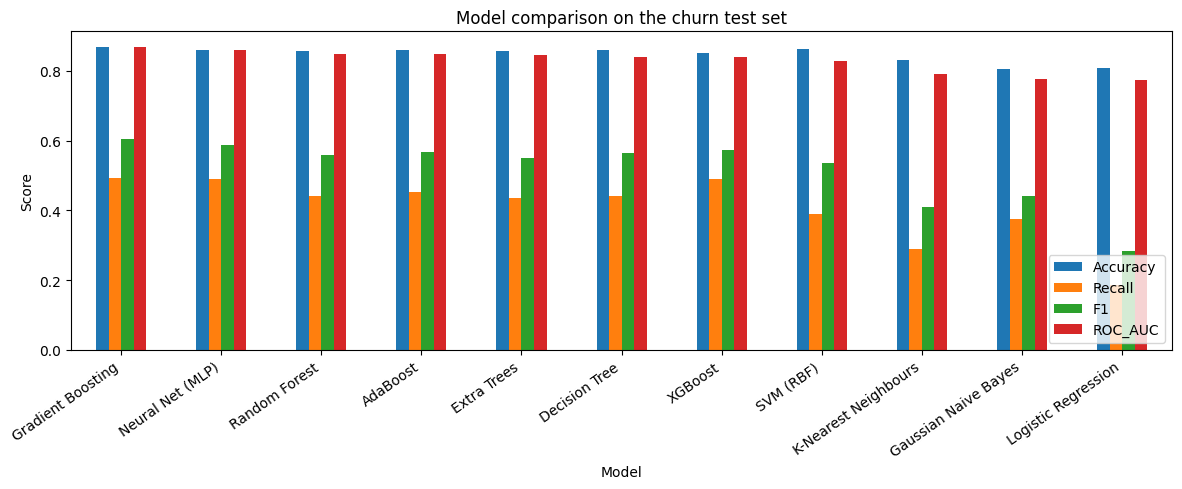

In [8]:
ax = results[['Accuracy','Recall','F1','ROC_AUC']].plot(kind='bar', figsize=(12,5))
plt.title('Model comparison on the churn test set'); plt.ylabel('Score')
plt.xticks(rotation=35, ha='right'); plt.legend(loc='lower right'); plt.tight_layout(); plt.show()

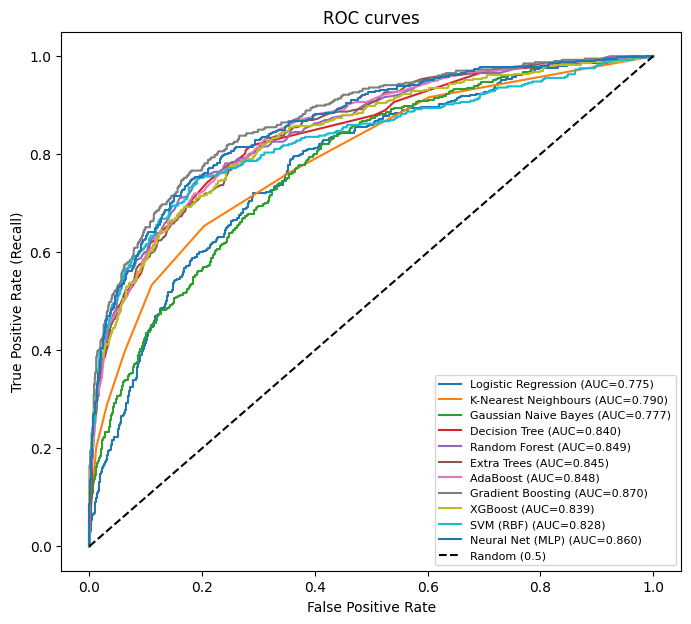

In [9]:
# ROC curves: the higher and more to the top-left, the better
plt.figure(figsize=(8,7))
for name,(fpr,tpr,_) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name} (AUC={results.loc[name,"ROC_AUC"]:.3f})')
plt.plot([0,1],[0,1],'k--', label='Random (0.5)')
plt.xlabel('False Positive Rate'); plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC curves'); plt.legend(fontsize=8, loc='lower right'); plt.show()

## 7. Look closely at the best model

Best model by ROC-AUC: Gradient Boosting


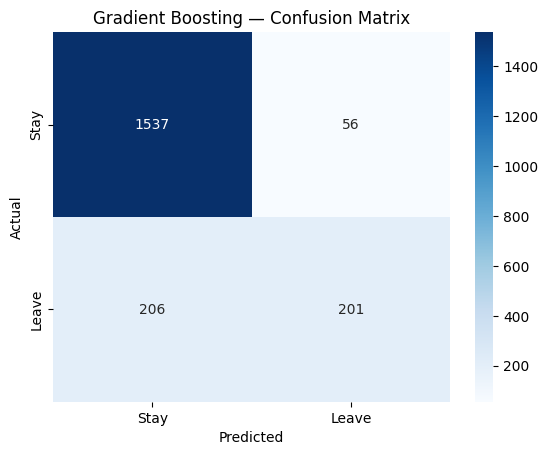

              precision    recall  f1-score   support

    Stay (0)       0.88      0.96      0.92      1593
   Leave (1)       0.78      0.49      0.61       407

    accuracy                           0.87      2000
   macro avg       0.83      0.73      0.76      2000
weighted avg       0.86      0.87      0.86      2000



In [10]:
best_name = results.index[0]
best_model = models[best_name]
print('Best model by ROC-AUC:', best_name)

pred = best_model.predict(X_test_s)
cm = confusion_matrix(y_test, pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Stay','Leave'], yticklabels=['Stay','Leave'])
plt.xlabel('Predicted'); plt.ylabel('Actual'); plt.title(f'{best_name} — Confusion Matrix'); plt.show()

print(classification_report(y_test, pred, target_names=['Stay (0)','Leave (1)']))

## 8. Builder move: boost recall by handling the imbalance
The default models tend to under-catch churners because leavers are rare. A builder fixes this by telling the model the rare class matters more — `scale_pos_weight` in XGBoost (or `class_weight='balanced'` elsewhere). This trades a little precision for a lot more recall, which is usually the right call for a churn programme.

In [11]:
ratio = (y_train == 0).sum() / (y_train == 1).sum()   # ~4 (because 80/20)
xgb_balanced = XGBClassifier(eval_metric='logloss', random_state=SEED,
                             scale_pos_weight=ratio)
xgb_balanced.fit(X_train_s, y_train)
pred_b = xgb_balanced.predict(X_test_s)
print('Recall before balancing :', round(recall_score(y_test, models['XGBoost'].predict(X_test_s)),3))
print('Recall after  balancing :', round(recall_score(y_test, pred_b),3))
print()
print(classification_report(y_test, pred_b, target_names=['Stay (0)','Leave (1)']))

Recall before balancing : 0.491
Recall after  balancing : 0.641

              precision    recall  f1-score   support

    Stay (0)       0.91      0.87      0.89      1593
   Leave (1)       0.56      0.64      0.60       407

    accuracy                           0.83      2000
   macro avg       0.73      0.76      0.74      2000
weighted avg       0.84      0.83      0.83      2000



## 9. Which features drive churn?
Tree models can tell us which inputs matter most — useful for the business, not just the prediction.

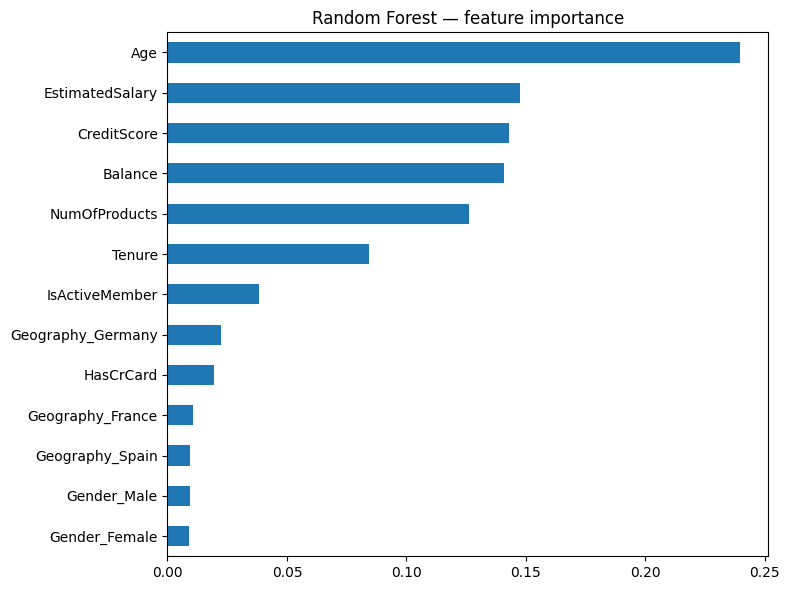

In [12]:
importances = pd.Series(models['Random Forest'].feature_importances_, index=X.columns)
importances.sort_values().plot(kind='barh', figsize=(8,6))
plt.title('Random Forest — feature importance'); plt.tight_layout(); plt.show()

## Takeaways
- The **boosted tree models (XGBoost, Gradient Boosting) and the ensembles (Random Forest, Extra Trees)** usually top the leaderboard on this dataset, clearly beating the simple linear and Naive Bayes baselines.
- On **80/20 imbalanced** data, accuracy looks high for everyone; the honest separators are **ROC-AUC, F1 and recall**.
- A simple **`scale_pos_weight`** adjustment lifts recall on churners substantially — the kind of practical tuning a builder reaches for.
- **Age, number of products, balance and active-membership** typically come out as the strongest churn drivers, which the bank can act on.